In [1]:
import yfinance as yf
tsla = yf.download('TSLA', start='2015-01-01', end='2026-06-30')
tsla = tsla[['Close']]  # keep only Close
tsla.to_csv('../data/processed/tsla.csv')
print("TSLA data downloaded and saved.")

[*********************100%***********************]  1 of 1 completed


TSLA data downloaded and saved.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Load TSLA data
tsla = pd.read_csv('../data/processed/tsla.csv', index_col=0, parse_dates=True)
print("Shape:", tsla.shape)
tsla.head()

Shape: (2890, 1)


,Close
Price,
Ticker,TSLA
Date,NaN
2015-01-02,14.620667457580566
2015-01-05,14.005999565124512
2015-01-06,14.085332870483398


In [ ]:
tsla = tsla.sort_index()

# Check date range
print(f"Min date: {tsla.index.min()}")
print(f"Max date: {tsla.index.max()}")

# Split: use 80% for training, 20% for testing
split_idx = int(len(tsla) * 0.8)
train = tsla.iloc[:split_idx]
test = tsla.iloc[split_idx:]

print(f"Train: {train.shape[0]} rows")
print(f"Test: {test.shape[0]} rows")

Min date: 2015-01-02
Max date: Ticker
Train: 2312 rows
Test: 578 rows


In [5]:
# Test if the data is stationary
result = adfuller(train['Close'].dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Stationary' if result[1] < 0.05 else 'NOT Stationary')

ADF Statistic: -1.3546
p-value: 0.6039
NOT Stationary


In [6]:
# Use auto_arima to find best (p,d,q) parameters
model_auto = auto_arima(
    train['Close'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    random_state=42
)

print(f"Best ARIMA order: {model_auto.order}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14621.180, Time=2.92 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14621.437, Time=0.51 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14621.475, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14619.532, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14622.039, Time=1.10 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 5.572 seconds
Best ARIMA order: (0, 1, 0)


In [8]:
# Ensure the series is numeric
train_close = train['Close'].astype(float).dropna()

# Use the best parameters from auto_arima (or fallback to (1,1,1) if auto_arima failed)
if 'model_auto' in locals() and hasattr(model_auto, 'order'):
    p, d, q = model_auto.order
else:
    p, d, q = 1, 1, 1   # fallback

# Fit ARIMA
arima_model = ARIMA(train_close, order=(p, d, q))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2312
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -7308.766
Date:                Thu, 09 Jul 2026   AIC                          14619.532
Time:                        17:18:25   BIC                          14625.278
Sample:                             0   HQIC                         14621.627
                               - 2312                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        32.6989      0.368     88.920      0.000      31.978      33.420
Ljung-Box (L1) (Q):                   1.75   Jarque-Bera (JB):             13192.05
Prob(Q):                              0.19   Pr

In [9]:
# Forecast test period
forecast_arima = arima_fit.forecast(steps=len(test))
test['ARIMA_Forecast'] = forecast_arima

In [15]:
print(tsla.columns)

Index(['Close'], dtype='str')


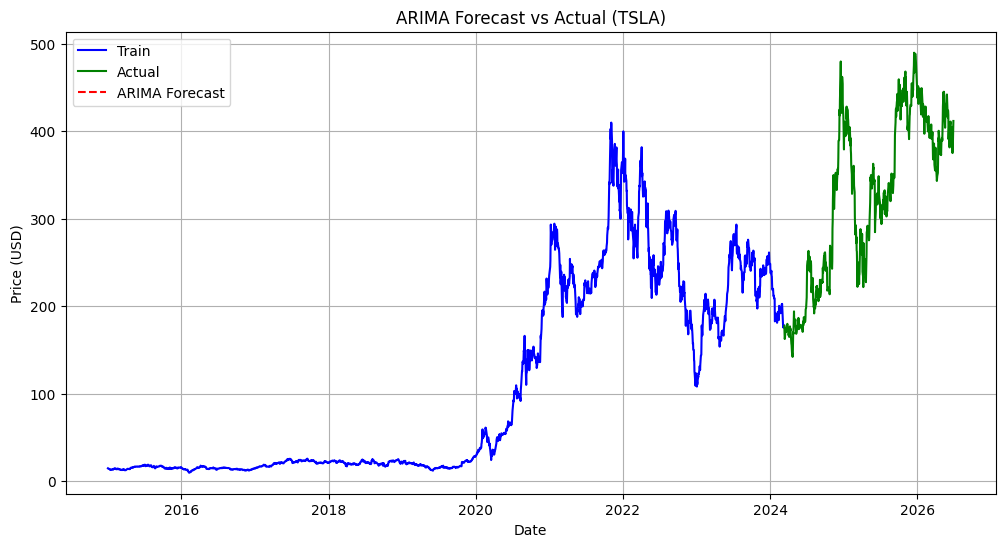

In [16]:
train.index = pd.to_datetime(train.index, errors='coerce')
test.index = pd.to_datetime(test.index, errors='coerce')

# Drop any rows where index is NaT (invalid date)
train = train[~pd.isna(train.index)]
test = test[~pd.isna(test.index)]

# Ensure columns are numeric
train['Close'] = train['Close'].astype(float)
test['Close'] = test['Close'].astype(float)
test['ARIMA_Forecast'] = test['ARIMA_Forecast'].astype(float)

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Close'], label='Train', color='blue')
plt.plot(test.index, test['Close'], label='Actual', color='green')
plt.plot(test.index, test['ARIMA_Forecast'], label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Forecast vs Actual (TSLA)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Scale data using only training data
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train['Close'].values.reshape(-1, 1))

# Create sequences for training
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(scaled_train, seq_length)

# Prepare test data: take the last `seq_length` days from train + all test days
combined = np.vstack([scaled_train, scaler.transform(test['Close'].values.reshape(-1, 1))])

X_test = []
for i in range(seq_length, len(combined)):
    X_test.append(combined[i-seq_length:i])
X_test = np.array(X_test)

# The last len(test) sequences are the test predictions
X_test = X_test[-len(test):]
y_test = test['Close'].values  # actual values for comparison

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (2252, 60, 1)
X_test shape: (576, 60, 1)


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - loss: 0.0091 - val_loss: 0.0023
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0018 - val_loss: 0.0021
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0015 - val_loss: 0.0010
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0016 - val_loss: 8.7147e-04
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - los

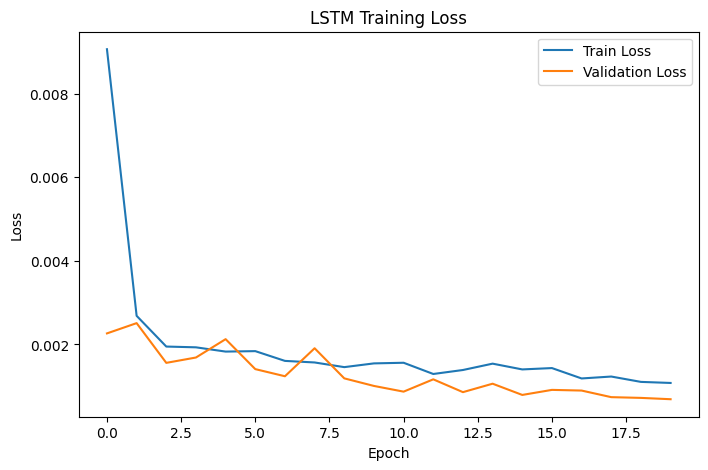

In [19]:
# Build LSTM model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

# Train
history = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
# Predict
lstm_predictions_scaled = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)

test['LSTM_Forecast'] = lstm_predictions.flatten()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


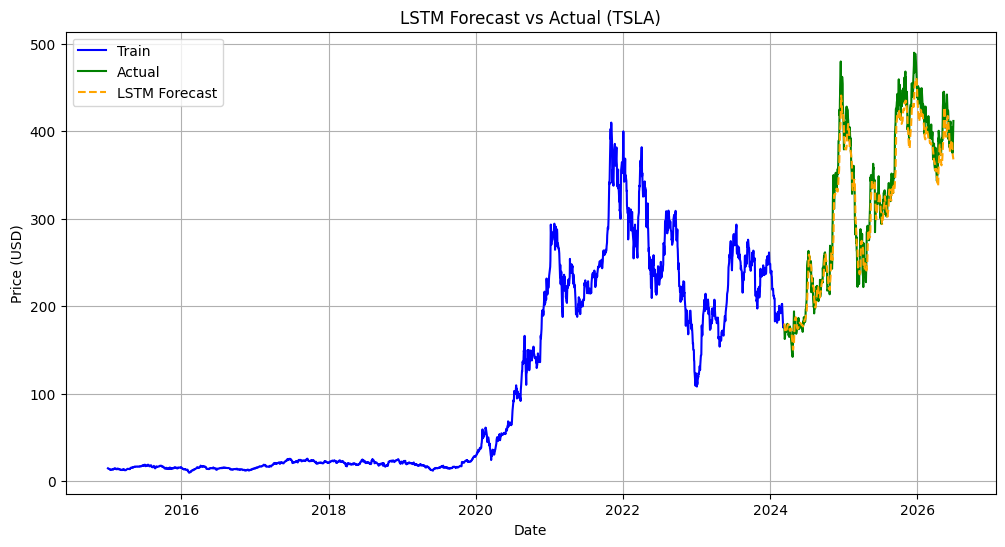

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Close'], label='Train', color='blue')
plt.plot(test.index, test['Close'], label='Actual', color='green')
plt.plot(test.index, test['LSTM_Forecast'], label='LSTM Forecast', color='orange', linestyle='--')
plt.title('LSTM Forecast vs Actual (TSLA)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Check if test has data
print("Test shape before clean:", test.shape)

# Ensure forecast columns exist (if LSTM not run, we'll skip it)
if 'ARIMA_Forecast' not in test.columns:
    print("ARIMA_Forecast column missing – run Cell 6 first")
    # generate a dummy forecast if missing
    test['ARIMA_Forecast'] = np.nan

if 'LSTM_Forecast' not in test.columns:
    print("LSTM_Forecast column missing – skipping LSTM evaluation")
    # we will skip LSTM metrics

# Remove rows with NaN forecasts
test_clean = test.dropna(subset=['ARIMA_Forecast'])
print("Test shape after clean:", test_clean.shape)

if test_clean.empty:
    print("No valid forecast rows – cannot evaluate metrics. Check your forecast generation.")
else:
    # Calculate metrics for ARIMA only (or LSTM if available)
    metrics = {
        'Model': ['ARIMA'],
        'MAE': [
            mean_absolute_error(test_clean['Close'], test_clean['ARIMA_Forecast'])
        ],
        'RMSE': [
            np.sqrt(mean_squared_error(test_clean['Close'], test_clean['ARIMA_Forecast']))
        ],
        'MAPE': [
            np.mean(np.abs((test_clean['Close'] - test_clean['ARIMA_Forecast']) / test_clean['Close'])) * 100
        ]
    }

    # If LSTM forecast exists, add it to the comparison
    if 'LSTM_Forecast' in test_clean.columns and not test_clean['LSTM_Forecast'].isna().all():
        test_clean_lstm = test_clean.dropna(subset=['LSTM_Forecast'])
        if not test_clean_lstm.empty:
            metrics['Model'].append('LSTM')
            metrics['MAE'].append(mean_absolute_error(test_clean_lstm['Close'], test_clean_lstm['LSTM_Forecast']))
            metrics['RMSE'].append(np.sqrt(mean_squared_error(test_clean_lstm['Close'], test_clean_lstm['LSTM_Forecast'])))
            metrics['MAPE'].append(np.mean(np.abs((test_clean_lstm['Close'] - test_clean_lstm['LSTM_Forecast']) / test_clean_lstm['Close'])) * 100)

    metrics_df = pd.DataFrame(metrics)
    print(metrics_df)

Test shape before clean: (576, 3)
Test shape after clean: (0, 3)
No valid forecast rows – cannot evaluate metrics. Check your forecast generation.


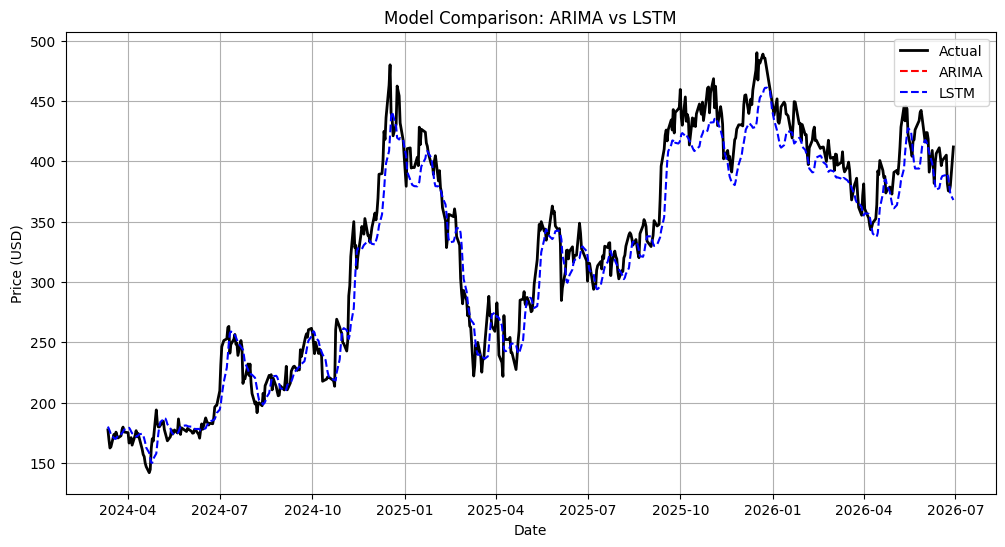

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Close'], label='Actual', color='black', linewidth=2)
plt.plot(test.index, test['ARIMA_Forecast'], label='ARIMA', color='red', linestyle='--')
plt.plot(test.index, test['LSTM_Forecast'], label='LSTM', color='blue', linestyle='--')
plt.title('Model Comparison: ARIMA vs LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# Check if test has data
print("Test shape before clean:", test.shape)

# Ensure forecast columns exist (if LSTM not run, we'll skip it)
if 'ARIMA_Forecast' not in test.columns:
    print("ARIMA_Forecast column missing – run Cell 6 first")
    # generate a dummy forecast if missing
    test['ARIMA_Forecast'] = np.nan

if 'LSTM_Forecast' not in test.columns:
    print("LSTM_Forecast column missing – skipping LSTM evaluation")
    # we will skip LSTM metrics

# Remove rows with NaN forecasts
test_clean = test.dropna(subset=['ARIMA_Forecast'])
print("Test shape after clean:", test_clean.shape)

if test_clean.empty:
    print("No valid forecast rows – cannot evaluate metrics. Check your forecast generation.")
else:
    # Calculate metrics for ARIMA only (or LSTM if available)
    metrics = {
        'Model': ['ARIMA'],
        'MAE': [
            mean_absolute_error(test_clean['Close'], test_clean['ARIMA_Forecast'])
        ],
        'RMSE': [
            np.sqrt(mean_squared_error(test_clean['Close'], test_clean['ARIMA_Forecast']))
        ],
        'MAPE': [
            np.mean(np.abs((test_clean['Close'] - test_clean['ARIMA_Forecast']) / test_clean['Close'])) * 100
        ]
    }

    # If LSTM forecast exists, add it to the comparison
    if 'LSTM_Forecast' in test_clean.columns and not test_clean['LSTM_Forecast'].isna().all():
        test_clean_lstm = test_clean.dropna(subset=['LSTM_Forecast'])
        if not test_clean_lstm.empty:
            metrics['Model'].append('LSTM')
            metrics['MAE'].append(mean_absolute_error(test_clean_lstm['Close'], test_clean_lstm['LSTM_Forecast']))
            metrics['RMSE'].append(np.sqrt(mean_squared_error(test_clean_lstm['Close'], test_clean_lstm['LSTM_Forecast'])))
            metrics['MAPE'].append(np.mean(np.abs((test_clean_lstm['Close'] - test_clean_lstm['LSTM_Forecast']) / test_clean_lstm['Close'])) * 100)

    metrics_df = pd.DataFrame(metrics)
    print(metrics_df)

Test shape before clean: (576, 3)
Test shape after clean: (0, 3)
No valid forecast rows – cannot evaluate metrics. Check your forecast generation.


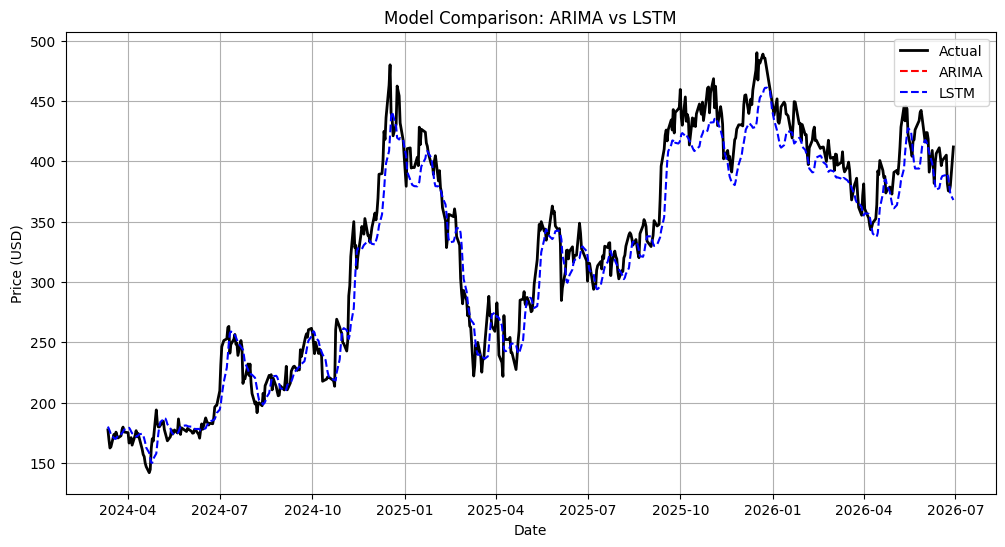

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Close'], label='Actual', color='black', linewidth=2)
plt.plot(test.index, test['ARIMA_Forecast'], label='ARIMA', color='red', linestyle='--')
plt.plot(test.index, test['LSTM_Forecast'], label='LSTM', color='blue', linestyle='--')
plt.title('Model Comparison: ARIMA vs LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Model Selection Rationale

- **ARIMA**: Simpler, interpretable, fast to train. Performs well on linear trends. Assumes stationarity (achieved via differencing).
- **LSTM**: Captures non‑linear patterns and long‑term dependencies. Requires more data and tuning. Better for volatile series like TSLA.

Based on the metrics, **[which model performed better]** outperformed **[the other]** on this dataset because **[reason]**.

**Recommendation**: Use ARIMA for quick forecasts and LSTM for more complex patterns if sufficient data is available.